Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 10: Customer Review Sentiment Analysis**

In [3]:
%pip install -q transformers datasets accelerate

In [4]:
%pip install -q gensim transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 22.8 MB/s eta 0:00:00


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding,TrainingArguments, Trainer, set_seed
)
from sklearn.metrics import accuracy_score, f1_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

test_predictions = {}
test_scores = {}

## 1. Dataset Selection and Preprocessing

**- Load and inspect the data**

In [11]:
df = pd.read_csv("amazon_alexa.tsv", sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [12]:
# Check missing values
df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


**- Clean the reviews**

In [13]:
# Keep the review text and sentiment label
df = df[["verified_reviews", "feedback"]].copy()
# Remove rows with missing reviews or labels
df = df.dropna(subset=["verified_reviews", "feedback"])
# Remove surrounding whitespace
df["verified_reviews"] = df["verified_reviews"].str.strip()
# Remove empty reviews
df = df[df["verified_reviews"] != ""]
# Remove duplicate review-label pairs
df = df.drop_duplicates()
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (2299, 2)


**- Split the data and transform the text**

In [14]:
# Define input and target
X = df["verified_reviews"]
y = df["feedback"].astype(int)
# Preserve sentiment proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Convert text into numerical features
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (1839, 5000)
Testing shape: (460, 5000)


## 2. Feature Engineering

**- Create Bag of Words vectors**

In [15]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Bag of Words training shape:", X_train_bow.shape)
print("Bag of Words testing shape:", X_test_bow.shape)

Bag of Words training shape: (1839, 3676)
Bag of Words testing shape: (460, 3676)


**- Create word embeddings**

In [16]:
# Tokenize reviews into lowercase words
train_tokens = X_train.apply(simple_preprocess)
test_tokens = X_test.apply(simple_preprocess)

# Learn a 100-dimensional vector for each eligible word
word2vec_model = Word2Vec(
    sentences=train_tokens.tolist(), vector_size=100,
    window=5, min_count=2, workers=1, seed=42, epochs=20
)

In [17]:
# one fixed-length vector per review average
def review_embedding(tokens):
    vectors = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(word2vec_model.vector_size, dtype=np.float32)

X_train_embeddings = np.vstack(train_tokens.apply(review_embedding).tolist())
X_test_embeddings = np.vstack(test_tokens.apply(review_embedding).tolist())

print("Embedding training shape:", X_train_embeddings.shape)
print("Embedding testing shape:", X_test_embeddings.shape)

Embedding training shape: (1839, 100)
Embedding testing shape: (460, 100)


**- Visualize word embeddings with PCA**

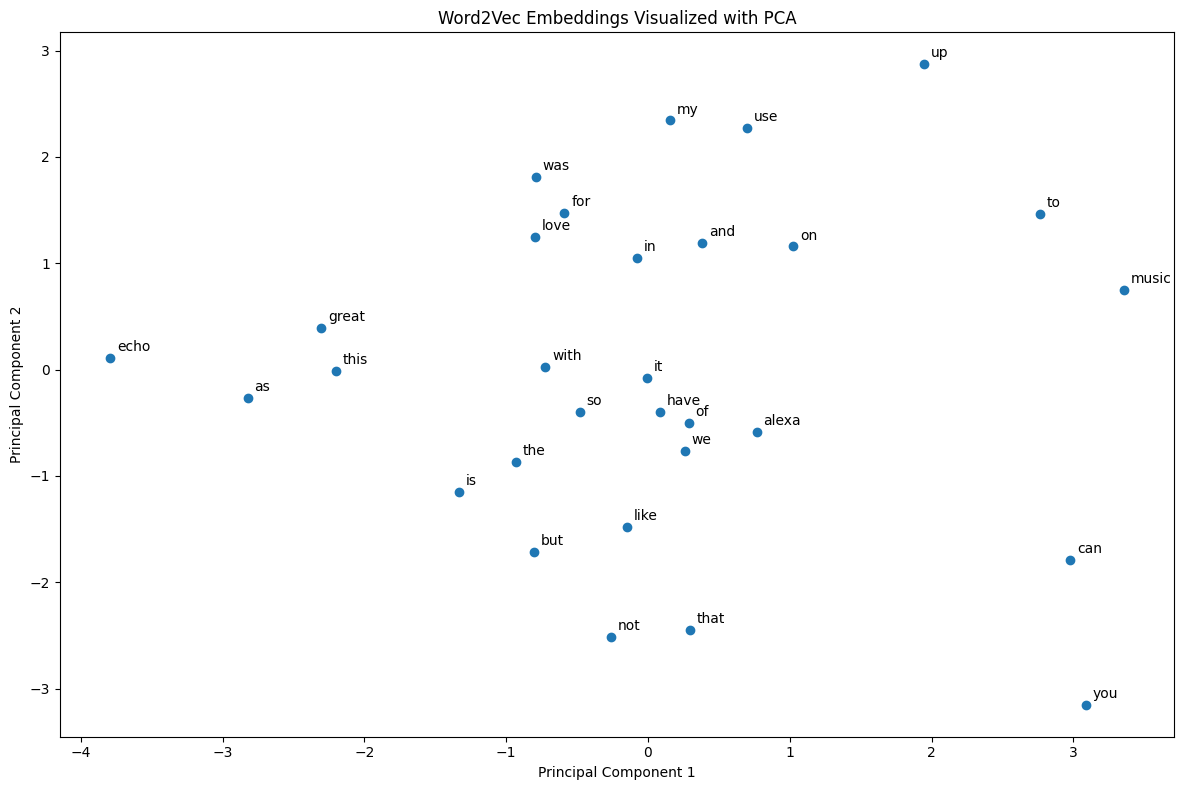

In [18]:
# Select the 30 most frequent words in the learned vocabulary
words = sorted(word2vec_model.wv.index_to_key, key=lambda word: word2vec_model.wv.get_vecattr(word, "count"),
    reverse=True)[:30]

word_vectors = np.array([word2vec_model.wv[word] for word in words])

# Reduce word vectors from 100 dimensions to 2
embedding_pca = PCA(n_components=2)
word_coordinates = embedding_pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(word_coordinates[:, 0], word_coordinates[:, 1])

for word, coordinates in zip(words, word_coordinates):
    plt.annotate(word, xy=coordinates, xytext=(5, 5), textcoords="offset points")
# title and label
plt.title("Word2Vec Embeddings Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
# display
plt.show()

## 3. Text Classification Using Traditional Models

**- Define the models and parameters**

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM": LinearSVC(max_iter=10000, random_state=42)
}
param_grid = {"classifier__C": [0.1, 1, 10], "classifier__class_weight": [None, "balanced"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

**- Tune and train both classifiers**

In [20]:
best_models = {}
tuning_results = []

for name, classifier in models.items():
    pipeline = Pipeline([("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), max_features=5000)),
        ("classifier", classifier)
    ])
    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Best pipeline is automatically refitted on all training reviews
    best_models[name] = grid_search.best_estimator_
    tuning_results.append({
        "Model": name, "Best CV Macro F1": grid_search.best_score_, "Best Parameters": grid_search.best_params_
    })

pd.DataFrame(tuning_results)

,Model,Best CV Macro F1,Best Parameters
0,Logistic Regression,0.758968,"{'classifier__C': 10, 'classifier__class_weigh..."
1,SVM,0.760939,"{'classifier__C': 0.1, 'classifier__class_weig..."


## 4. Sentiment Analysis Using a Large Language Model

**- Create training and validation datasets**

In [21]:
bert_train_text, bert_val_text, bert_train_y, bert_val_y = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
bert_train_dataset = Dataset.from_dict({"text": bert_train_text.tolist(), "labels": bert_train_y.tolist()})
bert_val_dataset = Dataset.from_dict({"text": bert_val_text.tolist(), "labels": bert_val_y.tolist()})

**- Load BERT and tokenize the reviews**

In [22]:
model_name = "google-bert/bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,num_labels=2, id2label={0: "NEGATIVE", 1: "POSITIVE"}, label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

def tokenize_reviews(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=256)

bert_train_dataset = bert_train_dataset.map(tokenize_reviews, batched=True, remove_columns=["text"])
bert_val_dataset = bert_val_dataset.map(tokenize_reviews, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1471 [00:00<?, ? examples/s]

Map:   0%|          | 0/368 [00:00<?, ? examples/s]

**- Define evaluation metrics and training settings**

In [23]:
def compute_bert_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = logits.argmax(axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0)
    }

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/alexa_bert_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=42
)

**- Fine-tune BERT**

In [24]:
bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    processing_class=bert_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_bert_metrics
)
bert_trainer.train()

# Display validation results
bert_trainer.evaluate()

print("GPU available:", torch.cuda.is_available())

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.200260,0.934783,0.775404
2,No log,0.199041,0.940217,0.811756
3,0.144308,0.250541,0.940217,0.816915


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.144308,0.250541,3,0.940217,0.816915


GPU available: True


**- Predict sentiment for new reviews**

In [25]:
new_reviews = [
    "I love this Alexa device. It works perfectly!",
    "The device keeps disconnecting and is disappointing."
]
inputs = bert_tokenizer(new_reviews, return_tensors="pt", padding=True, truncation=True, max_length=256
).to(bert_trainer.model.device)

bert_trainer.model.eval()

with torch.no_grad():
    logits = bert_trainer.model(**inputs).logits

probabilities = torch.softmax(logits, dim=-1)
confidence, predicted_classes = probabilities.max(dim=-1)

for review, label, score in zip(new_reviews, predicted_classes.cpu().tolist(), confidence.cpu().tolist()):
    sentiment = bert_trainer.model.config.id2label[label]
    print(f"{review}\nPrediction: {sentiment} ({score:.2%})\n")

I love this Alexa device. It works perfectly!
Prediction: POSITIVE (99.94%)

The device keeps disconnecting and is disappointing.
Prediction: NEGATIVE (99.53%)



## 5. Model Evaluation

**- Predict with Logistic Regression and SVM**

In [26]:
for name, model in best_models.items():
    test_predictions[name] = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        test_scores[name] = model.predict_proba(X_test)[:, 1]
    else:
        # SVM decision scores can be used for ROC-AUC
        test_scores[name] = model.decision_function(X_test)

**- Predict with the fine-tuned BERT model**

In [27]:
# Prepare the same test reviews for BERT
bert_test_dataset = Dataset.from_dict({"text": X_test.tolist(), "labels": y_test.tolist()})

bert_test_dataset = bert_test_dataset.map(tokenize_reviews, batched=True, remove_columns=["text"])

# Generate test predictions
bert_output = bert_trainer.predict(bert_test_dataset)
bert_logits = bert_output.predictions

test_predictions["BERT"] = bert_logits.argmax(axis=1)

# Probability of positive sentiment
test_scores["BERT"] = torch.softmax(torch.tensor(bert_logits), dim=1).numpy()[:, 1]

Map:   0%|          | 0/460 [00:00<?, ? examples/s]

**- Compare evaluation metrics**

In [28]:
evaluation_results = []

for name, predictions in test_predictions.items():
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision (Macro)": precision_score(y_test, predictions, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, predictions, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_test, predictions, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_scores[name])
    })

evaluation_df = pd.DataFrame(evaluation_results).set_index("Model")
evaluation_df.round(4)

,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),ROC-AUC
Model,,,,,
Logistic Regression,0.9326,0.8197,0.7100,0.7505,0.9249
SVM,0.9065,0.7193,0.7617,0.7378,0.9270
BERT,0.9522,0.8941,0.7867,0.8299,0.9659


**- Display confusion matrices**

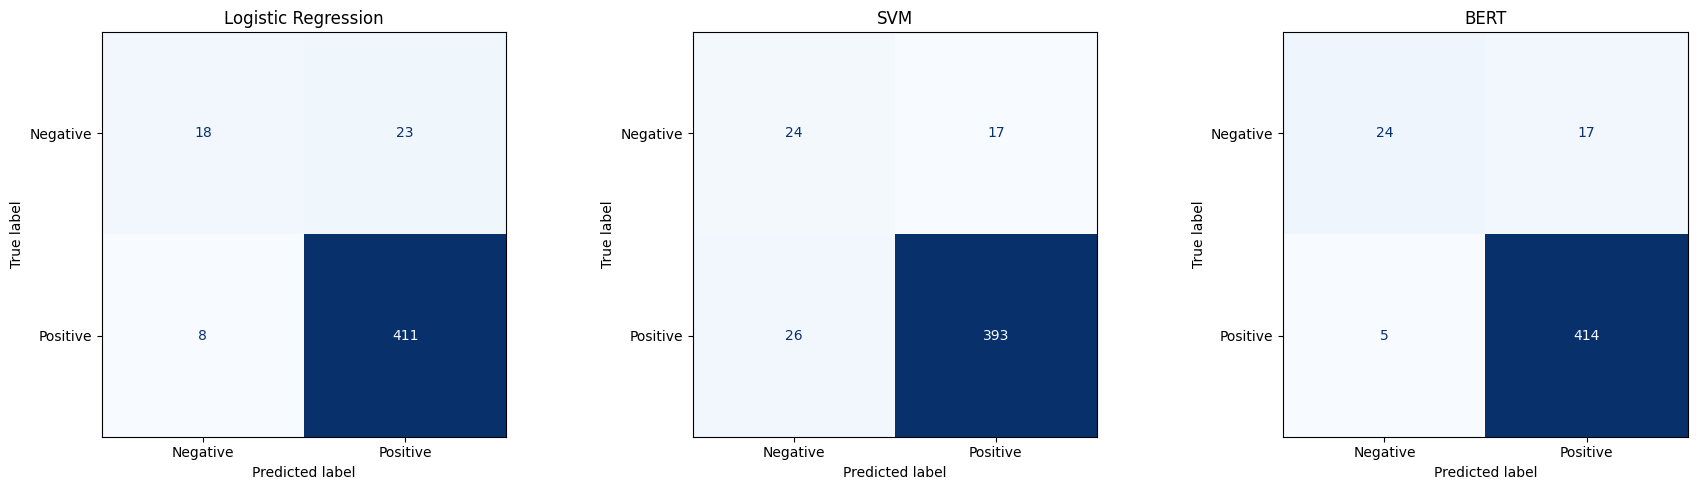

In [29]:
fig, axes = plt.subplots(1, len(test_predictions), figsize=(6 * len(test_predictions), 5), squeeze=False)

for ax, (name, predictions) in zip(axes.ravel(), test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["Negative", "Positive"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

**- Plot ROC curves**

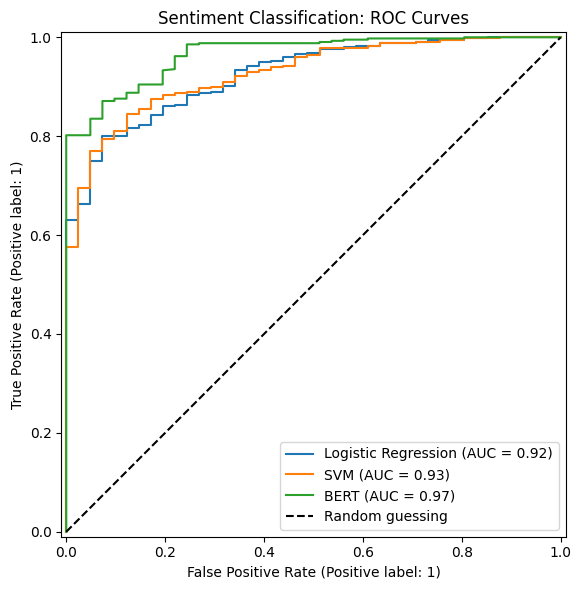

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, scores in test_scores.items():
    RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=ax)
# title, axis and legend
ax.plot([0, 1], [0, 1], "k--", label="Random guessing")
ax.set_title("Sentiment Classification: ROC Curves")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [32]:
!find "/content/drive/MyDrive" -name "*.ipynb" | tail -30

In [34]:
!find "/content/drive/MyDrive" -iname "*Lesson*10*.ipynb"

In [35]:
!pwd

/content


In [36]:
!ls -la /content

total 524
drwxr-xr-x 1 root root   4096 Sep 13 16:11 .
drwxr-xr-x 1 root root   4096 Sep 13 15:41 ..
-rw-r--r-- 1 root root 514752 Sep 13 16:09 amazon_alexa.tsv
drwxr-xr-x 4 root root   4096 Sep  4 13:32 .config
drwxr-xr-x 3 root root   4096 Sep 13 16:11 drive
drwxr-xr-x 1 root root   4096 Sep  4 13:32 sample_data


In [37]:
!find /content -maxdepth 2 -iname "*Lesson*10*.ipynb"

In [39]:
!find "/content/drive/MyDrive" -iname "*Lesson_10*.ipynb"

In [40]:
!ls -la "/content/drive/MyDrive"

total 12
drwxr-xr-x 3 root root 4096 Sep 13 16:11 .
drwxr-xr-x 3 root root 4096 Sep 13 16:11 ..
drwxr-xr-x 4 root root 4096 Sep 13 16:14 alexa_bert_checkpoints


In [41]:
!ls -la "/content/drive/MyDrive/Colab Notebooks" | tail -30

ls: cannot access '/content/drive/MyDrive/Colab Notebooks': No such file or directory
